In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import skimage
from skimage.transform import resize

from simulated_ptychography_dataset import *


Energy: 8 keV
Wavelength: 0.155 nm
Distance to detector: 5.100 m
Fresnel number: 1.340e-07
Distance to focus: 3.000 mm
Rayleigh range: 7.30e-02 mm
Pixel size: 7.500e-05 m
Magnification: 1701.000 
Object pixel size: 1.029e-08 m
Effective pixel size: 4.409e-08 m
Effective distance to detector: 2.998e-03 m
Effective Fresnel number: 4.184e-03 
Original image shape: (2048, 2048) and (2048, 2048)


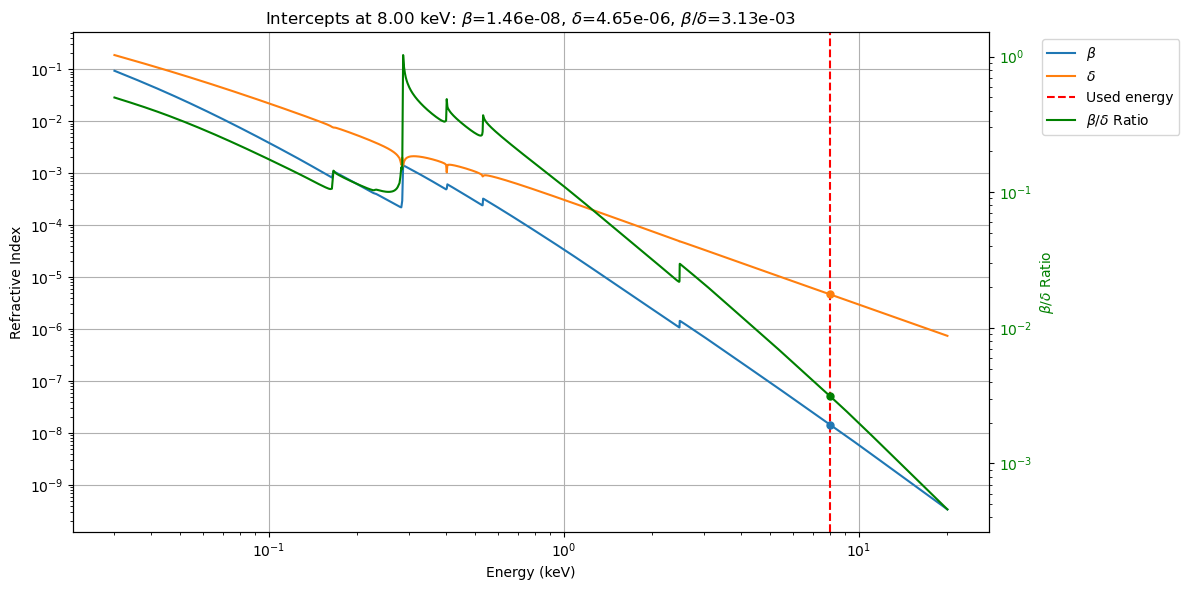

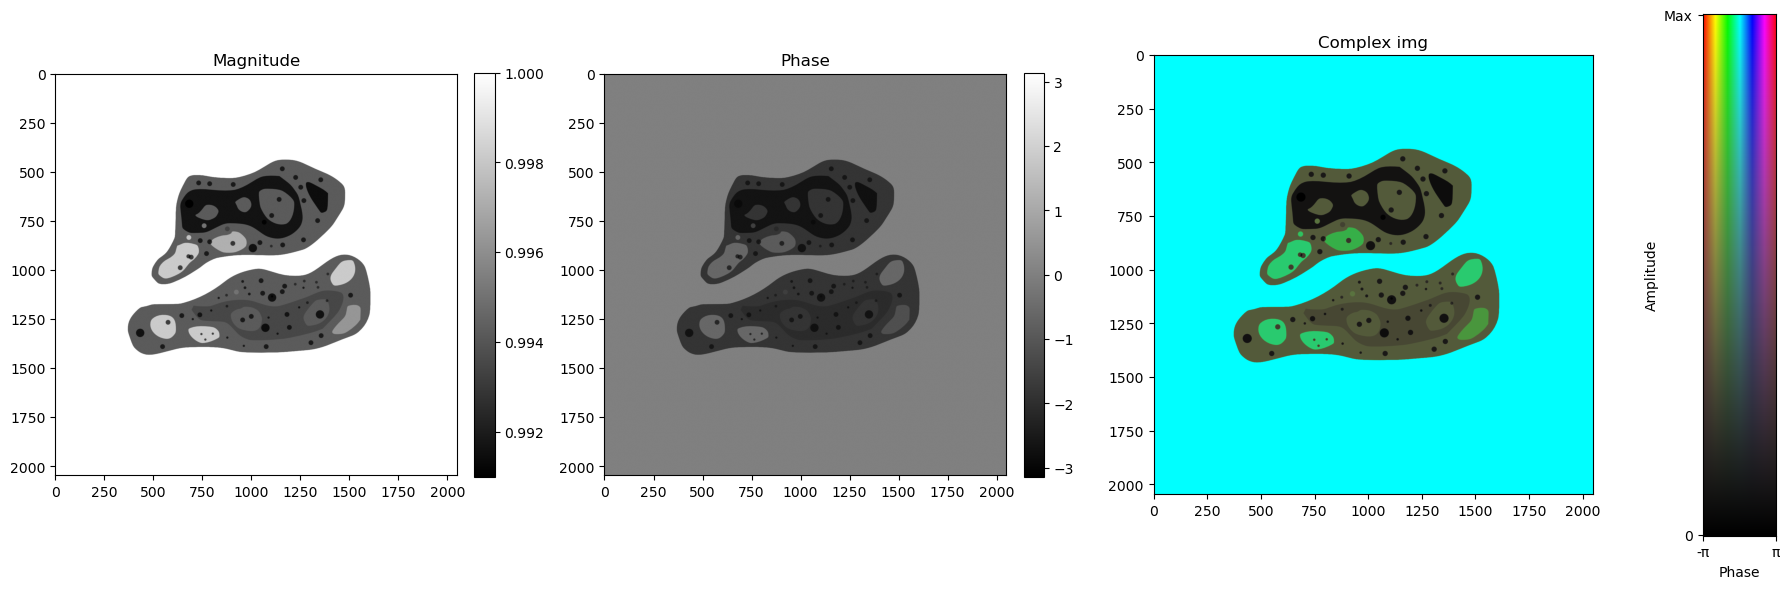

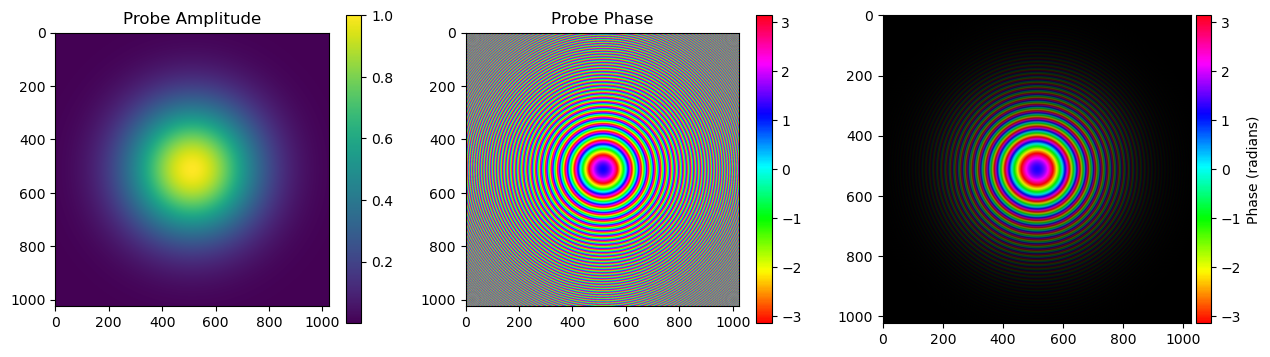

Desired counts per measurement: 6.440e+07
Total counts in probe intensity: 9.028e+04
Correction factor for probe intensity: 6.803e-04
Checking the probe intensity after scaling: 6.440e+07 counts
Initial mask shape: (1024, 1024)


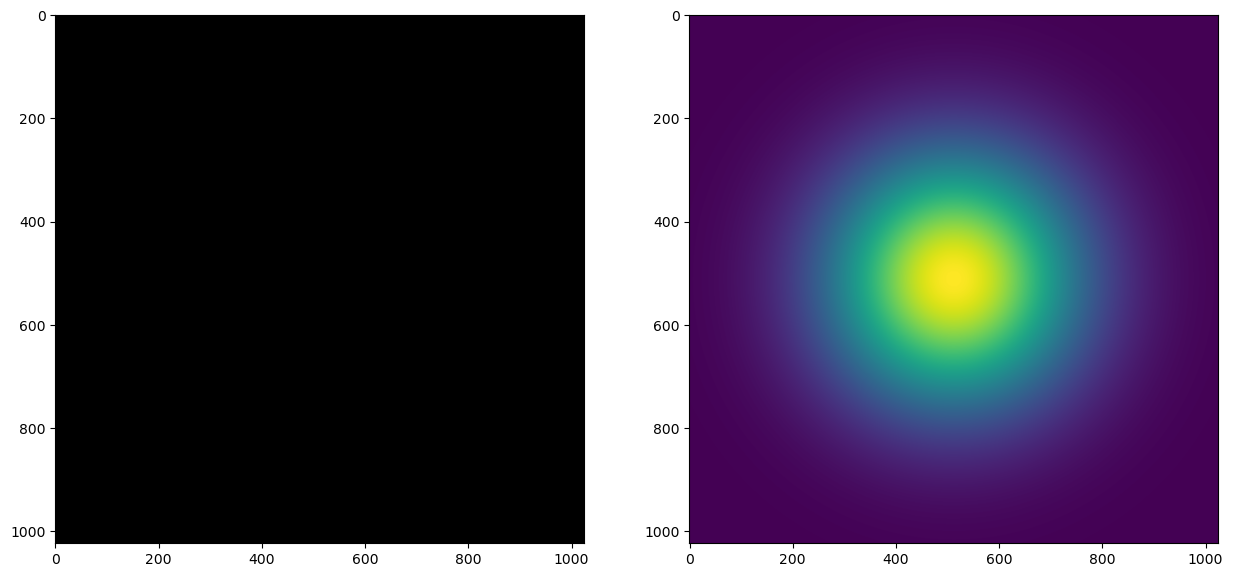

Probe shape: (1024, 1024). Object shape: (1024, 1024)
New object shape: (1024, 1024)
Whole object shape: (2011, 2026) Probe shape: (1024, 1024) Positions shape: (100, 3) Mask shape: (1024, 1024)


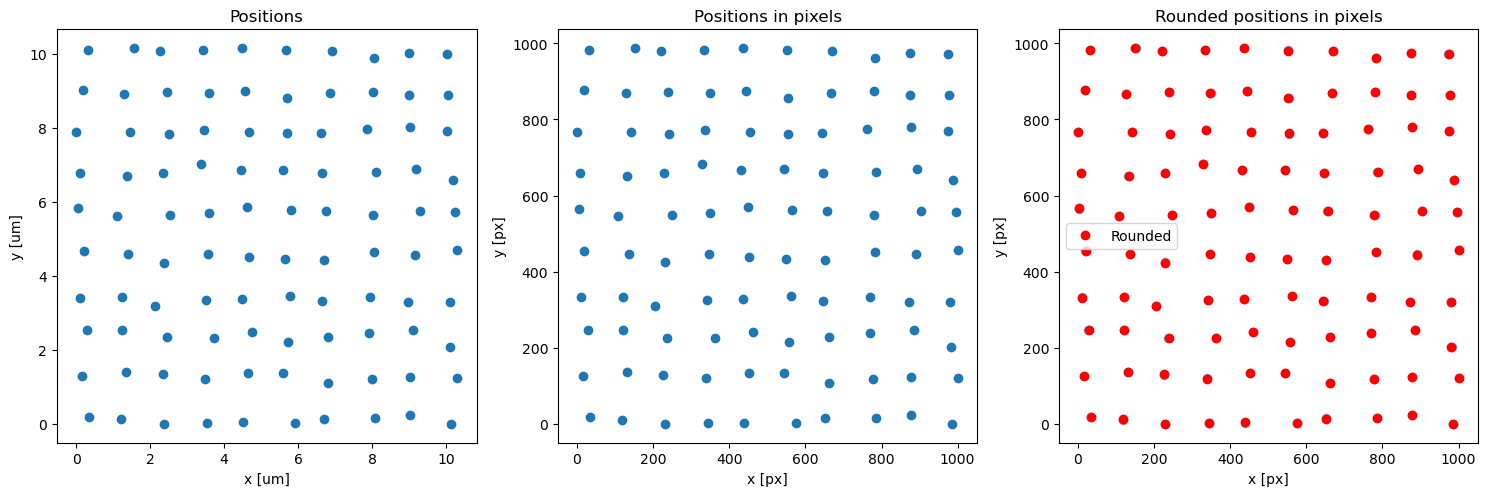

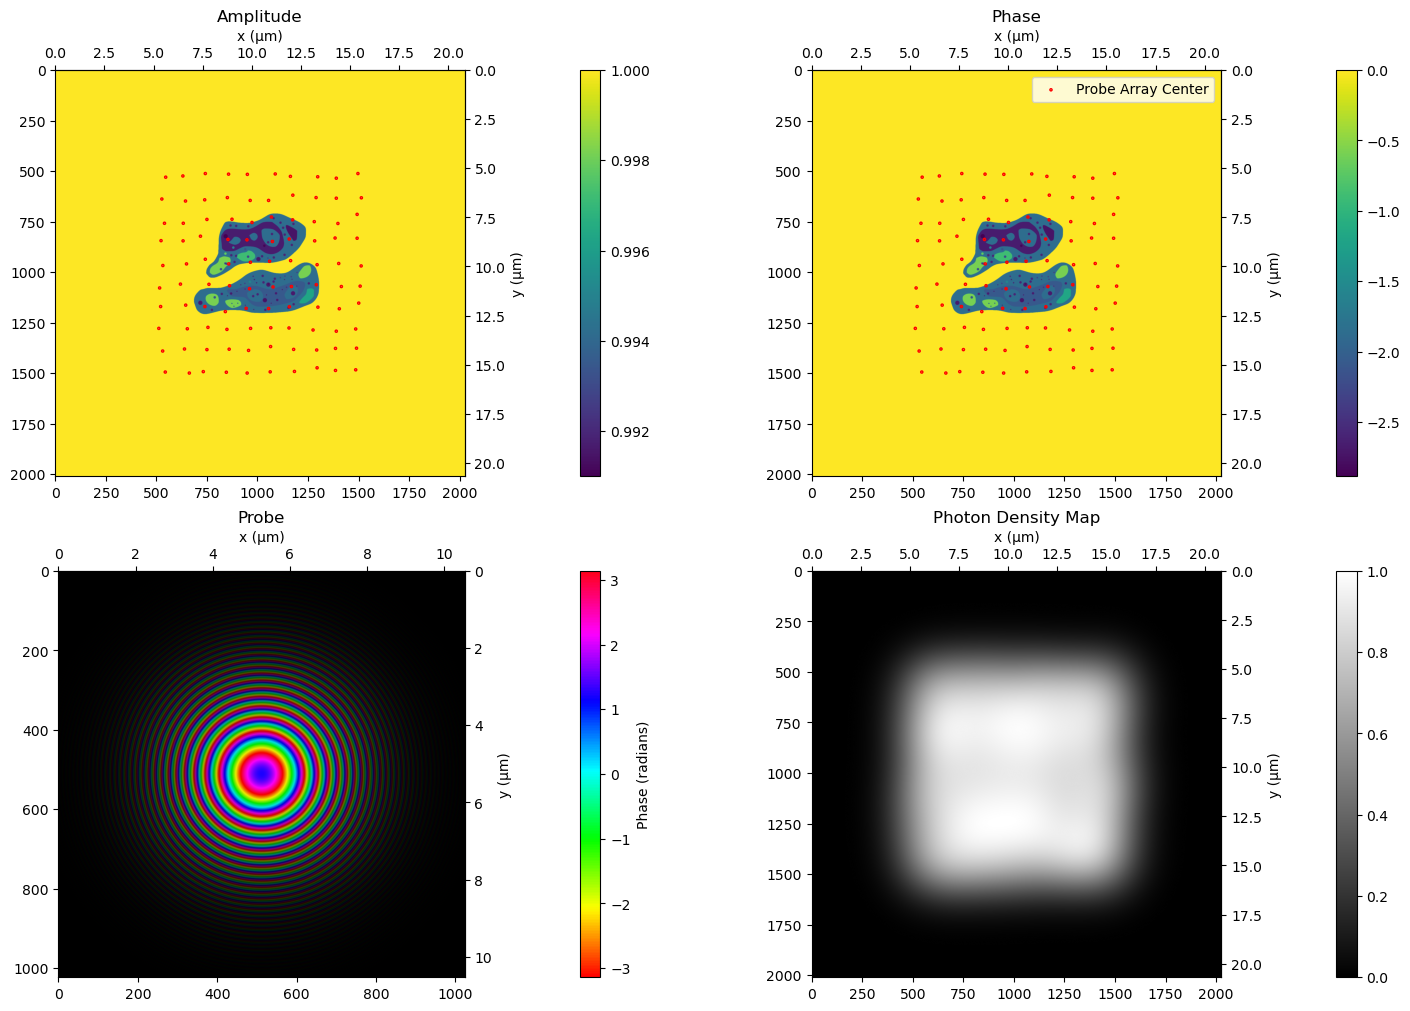

FresnelTFPropagator: Insufficient sampling for requested Fresnel numbers. Use at least 4388 sampling points in all axes. 


Saving data to jitter_010_points_1.11e+00_step_3.00e-03_dist.h5


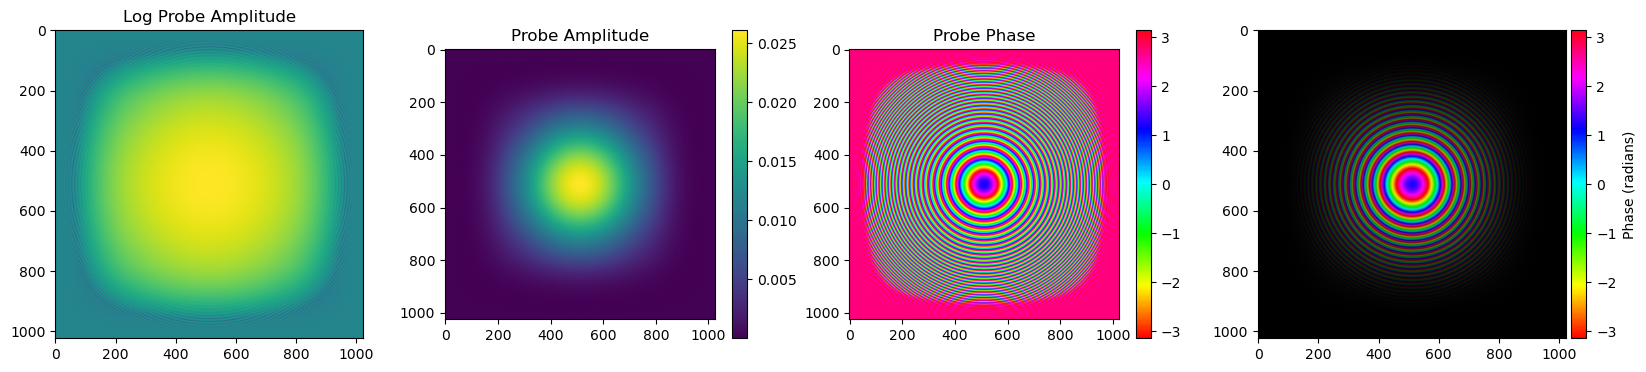

In [2]:
n_points = 10
n_of_pixels=1024 # n of detector pixels. Will be used to define the gaussian probe
detector_pixel = 75e-6  # eiger
z1 = 3e-3
z02 = 5.1+z1
z2=z02-z1
E_keV = 8
magnification = (z1+z2)/z1 # or  z02/z01
magnified_pixel = detector_pixel/magnification
magnified_distance = z2/magnification
wavelength = 1.23984 / E_keV * 1e-9  # Convert keV to meters
k_wavector = 2*np.pi/wavelength
obj_pixel = wavelength*z2/(n_of_pixels*detector_pixel)
w0 = 60e-9 # waist of gaussian beam (approx waveguide exit size?)
z0 = np.pi * w0**2 / wavelength  # Rayleigh range
fov= 12e-6 #10.54e-6

print(f"Energy: {E_keV} keV")
print(f"Wavelength: {1e9*wavelength:.3f} nm")
print(f"Distance to detector: {z2:.3f} m")
print(f"Fresnel number: {obj_pixel**2/(wavelength*z2):.3e}")
print(f"Distance to focus: {1e3*z1:.3f} mm")
print(f"Rayleigh range: {z0*1e3:.2e} mm")
print(f"Pixel size: {detector_pixel:.3e} m")
print(f"Magnification: {magnification:.3f} ")
print(f"Object pixel size: {obj_pixel:.3e} m")
print(f"Effective pixel size: {magnified_pixel:.3e} m")
print(f"Effective distance to detector: {magnified_distance:.3e} m")
print(f"Effective Fresnel number: {magnified_pixel**2/(wavelength*magnified_distance):.3e} ")

phantom = Phantom(source='dicty')
# complex_phantom = phantom.get_complex()
complex_phantom,beta, delta, betadelta_ratio = phantom.get_complex_with_betadelta(energy_keV=E_keV)

gravel = skimage.data.gravel()
gravel = resize(gravel, complex_phantom.shape, preserve_range=True)
gravel = gravel/np.max(gravel)
# complex_phantom += 0.1*gravel
# complex_phantom *= np.exp(1j*gravel)

if 0: # Add Gaussian noise to magnitude and phase
    noise_level_mag = 0.01  # adjust as needed
    noise_level_phase = 0.01  # adjust as needed

    magnitude = np.abs(complex_phantom)
    phase = np.angle(complex_phantom)

    magnitude_noisy = magnitude + np.random.normal(0, noise_level_mag, magnitude.shape)
    magnitude_noisy = np.clip(magnitude_noisy,None,1)
    phase_noisy = phase + np.random.normal(0, noise_level_phase, phase.shape)
    complex_phantom = magnitude_noisy * np.exp(1j * phase_noisy)

plot_amp_phase_complex(complex_phantom, colormap='gray')


if 1: # Gaussian probe

    z0 = np.pi * w0**2 / wavelength  # Rayleigh range
    probe = gaussian_beam(n_of_pixels, obj_pixel, z1, w0, wavelength)
    # probe = gaussian_beam_structured(n_of_pixels, obj_pixel, z1, w0, wavelength)

    probe = probe/np.max(np.abs(probe))  # Normalize the probe amplitude to 1

if 0: # Apply circular mask to probe if wanted
    circular_mask = np.zeros_like(probe)
    xx = np.arange(probe.shape[1])
    yy = np.arange(probe.shape[0])
    X, Y = np.meshgrid(xx, yy)
    circular_mask = (X-probe.shape[1]//2)**2 + (Y-probe.shape[0]//2)**2 < (probe.shape[1]//2-250)**2 

        
# Plot
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax1 = ax[0].imshow(np.abs(probe), cmap='viridis')
ax[0].set_title("Probe Amplitude")
fig.colorbar(ax1, ax=ax[0])
ax2 = ax[1].imshow(np.angle(probe), cmap='hsv')
ax[1].set_title("Probe Phase")
fig.colorbar(ax2, ax=ax[1])
RGB, sm = get_RGB_probe(probe, max_magnitude=np.abs(probe).max())
im = ax[2].imshow(RGB)
divider = make_axes_locatable(ax[2])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Phase (radians)")
plt.show()


desired_counts_per_measurement = 6.440e+07 # calculated value being declared directly; just faster
print(f"Desired counts per measurement: {desired_counts_per_measurement:.3e}")

total_counts_probe_intensity = np.sum(np.abs(probe)**2)
print(f"Total counts in probe intensity: {total_counts_probe_intensity:.3e}")

correction_factor = desired_counts_per_measurement / total_counts_probe_intensity / probe.size # factor to scale the probe intensity to match the desired counts
print(f"Correction factor for probe intensity: {correction_factor:.3e}")

probe = np.sqrt(correction_factor) * probe  # Scale the probe intensity to match desired counts

checking = np.sum(np.abs(np.fft.fftshift(np.fft.fft2(probe)))**2)  
print(f"Checking the probe intensity after scaling: {checking:.3e} counts")

xmin = -5 # microns
xmax = -xmin
ymin = -5
ymax = -ymin
# n_points = 10
grid_type = 'jitter'  # choose among 'raster', 'raster_noise' (or 'jitter'), 'fermat'

xexample = np.linspace(xmin, xmax, n_points)
step_size = xexample[1] - xexample[0]

# Returns positions (N,3) [z, y, x] in metres, snapped to pixel grid
positions, positions_pxls, positions_pxls_rounded = get_scan_positions(
    xmin, xmax, ymin, ymax, n_points, grid_type, z1=z1, obj_pixel=obj_pixel, plot=False
)

if 0: # get gaps/bad pixels mask
    import tifffile
    eiger_gaps = xraylab.irp.get_eiger_gaps()
    mask = eiger_gaps  # use only eiger gaps
    mask = mask[0:2048, 0:2048]  # crop to match probe shape
    mask = ~mask

    original_mask = mask.copy()  # keep original mask for later use

    mask = np.roll(mask, shift=(-350,300), axis=(0, 1))  # roll mask to center it

    mask = mask[512:-512, 512:-512]  # crop mask to match probe shape
else:
    mask = np.ones(probe.shape)
    mask = mask.astype(bool)
print(f"Initial mask shape: {mask.shape}")

fig, ax = plt.subplots(1,2,figsize=(15, 15))
ax[0].imshow(mask, cmap='gray')
ax[1].imshow(mask*np.abs(probe), cmap='viridis')
plt.show()

# Create another array of positions with errors    
positions_with_random_error = positions + np.random.uniform(-obj_pixel*0.7, obj_pixel*0.7, size=positions.shape)
error = np.sqrt((positions_pxls[:,-2]-positions_pxls_rounded[:,-2])**2 + (positions_pxls[:,-1]-positions_pxls_rounded[:,-1])**2)

# positions[:,-2] = y, positions[:,-1] = x  (columns are [z, y, x])
fig, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].plot(positions[:,-1]*1e6, positions[:,-2]*1e6, 'o')
ax[0].set_title('Positions')
ax[0].set_aspect('equal')
ax[0].set_xlabel('x [um]')
ax[0].set_ylabel('y [um]')
ax[1].plot(positions_pxls[:,-1], positions_pxls[:,-2], 'o')
ax[1].set_title('Positions in pixels')
ax[1].set_aspect('equal')
ax[1].set_xlabel('x [px]')
ax[1].set_ylabel('y [px]')
if 1:
    ax[2].plot(positions_pxls[:,-1], positions_pxls[:,-2], 'o',alpha=0.5)
    for (y_orig, x_orig), (y_round, x_round) in zip(positions_pxls[:,1:3], positions_pxls_rounded[:,1:3]):
        ax[2].plot([x_orig, x_round], [y_orig, y_round], 'k-',alpha=0.5)

ax[2].plot(positions_pxls_rounded[:,-1], positions_pxls_rounded[:,-2], 'ro',label='Rounded')
ax[2].set_title('Rounded positions in pixels')
ax[2].set_aspect('equal')
ax[2].set_xlabel('x [px]')
ax[2].set_ylabel('y [px]')
ax[2].legend(loc='best')
fig.tight_layout()

complex_obj = complex_phantom.copy()[0::2, 0::2]  # downsample by factor of 2
print(f"Probe shape: {probe.shape}. Object shape: {complex_obj.shape}")

complex_obj = pad_to_size(complex_obj, probe.shape[0]) # pad object to match probe size
print(f"New object shape: {complex_obj.shape}")


# Get new object array size given all scan positions
obj_shape = calculate_object_shape(positions_pxls_rounded, probe)
    
# Place complex_obj in the center of obj
start_y = (obj_shape[0] - complex_obj.shape[0]) // 2
start_x = (obj_shape[1] - complex_obj.shape[1]) // 2
obj = np.ones(obj_shape, dtype=np.complex64)
obj[start_y:start_y + complex_obj.shape[0], start_x:start_x + complex_obj.shape[1]] = complex_obj

print(f"Whole object shape: {obj.shape}", f"Probe shape: {probe.shape}", f"Positions shape: {positions.shape}", f'Mask shape: {mask.shape}')

# positions[:,1:3] gives the (y,x) columns in metres, as expected by calculate_photon_density_map
photon_density_map = calculate_photon_density_map(positions[:,1:3], probe, obj_shape, obj_pixel)
photon_density_map = photon_density_map/np.max(photon_density_map)

positions_xy = np.column_stack((positions_pxls_rounded[:, -1], positions_pxls_rounded[:, -2]))
positions_xy += probe.shape[0]//2
# Conversion functions: pixels <-> microns
pix_to_micron = lambda x: x * obj_pixel * 1e6
micron_to_pix = lambda x: x / (obj_pixel * 1e6)

# Create a 2x2 grid with constrained layout
fig, ax = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

#---------------------
# Top left: Amplitude
#---------------------
im0 = ax[0, 0].imshow(np.abs(obj), cmap='viridis')
fig.colorbar(im0, ax=ax[0, 0], fraction=0.046, pad=0.1)
ax[0, 0].set_title('Amplitude')
ax[0, 0].scatter(positions_xy[:, 0], positions_xy[:, 1], facecolors='none', edgecolors='red', marker='.', s=10)
secax_x00 = ax[0, 0].secondary_xaxis('top', functions=(pix_to_micron, micron_to_pix))
secax_x00.set_xlabel('x (µm)')
secax_y00 = ax[0, 0].secondary_yaxis('right', functions=(pix_to_micron, micron_to_pix))
secax_y00.set_ylabel('y (µm)')

#--------------------
# Top right: Phase
#--------------------
im1 = ax[0, 1].imshow(np.angle(obj), cmap='viridis')
fig.colorbar(im1, ax=ax[0, 1], fraction=0.046, pad=0.1)
ax[0, 1].set_title('Phase')
ax[0, 1].scatter(positions_xy[:, 0], positions_xy[:, 1], facecolors='none', edgecolors='red', marker='.', s=10,label='Probe Array Center')
ax[0,1].legend()
secax_x01 = ax[0, 1].secondary_xaxis('top', functions=(pix_to_micron, micron_to_pix))
secax_x01.set_xlabel('x (µm)')
secax_y01 = ax[0, 1].secondary_yaxis('right', functions=(pix_to_micron, micron_to_pix))
secax_y01.set_ylabel('y (µm)')

#--------------------
# Bottom left: Probe
#--------------------
RGB, sm = get_RGB_probe(probe, max_magnitude=np.abs(probe).max())
im2 = ax[1, 0].imshow(RGB)
cbar2 = fig.colorbar(sm, ax=ax[1, 0], fraction=0.046, pad=0.1)
cbar2.set_label("Phase (radians)")
ax[1, 0].set_title('Probe')
secax_x10 = ax[1, 0].secondary_xaxis('top', functions=(pix_to_micron, micron_to_pix))
secax_x10.set_xlabel('x (µm)')
secax_y10 = ax[1, 0].secondary_yaxis('right', functions=(pix_to_micron, micron_to_pix))
secax_y10.set_ylabel('y (µm)')

#------------------------------
# Bottom right: Photon Density Map
#------------------------------
im3 = ax[1, 1].imshow(photon_density_map, cmap='gray')
ax[1, 1].set_title('Photon Density Map')
fig.colorbar(im3, ax=ax[1, 1], fraction=0.046, pad=0.1)
secax_x11 = ax[1, 1].secondary_xaxis('top', functions=(pix_to_micron, micron_to_pix))
secax_x11.set_xlabel('x (µm)')
secax_y11 = ax[1, 1].secondary_yaxis('right', functions=(pix_to_micron, micron_to_pix))
secax_y11.set_ylabel('y (µm)')

plt.show()



filename = f"{grid_type}_{n_points:03}_points_{step_size:.2e}_step_{z1:.2e}_dist.h5"
print(f"Saving data to {filename}")


fresnel_number = obj_pixel**2/wavelength/magnified_distance
forward_propagator = FresnelTFPropagator(probe.shape,fresnel_number)

size_y,size_x = probe.shape

farfield_ptychogram = np.empty((positions_pxls_rounded.shape[0],size_y, size_x),dtype=np.float32)

if 1: #VIGNETTING:
    probe, _ = apply_vignette(probe, method='tukey', sigma=3)

# Plot
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
ax0 = ax[0].imshow(np.abs(probe),norm=LogNorm())
ax[0].set_title("Log Probe Amplitude")
ax1 = ax[1].imshow(np.abs(probe), cmap='viridis')
ax[1].set_title("Probe Amplitude")
fig.colorbar(ax1, ax=ax[1])
ax2 = ax[2].imshow(np.angle(probe), cmap='hsv')
ax[2].set_title("Probe Phase")
fig.colorbar(ax2,ax=ax[2])
RGB, sm = get_RGB_probe(probe, max_magnitude=np.abs(probe).max())
im = ax[3].imshow(RGB)
divider = make_axes_locatable(ax[3])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Phase (radians)")
plt.show()

count_list = []
for i, (_, posy, posx) in enumerate(positions_pxls_rounded):
    posy, posx = int(posy), int(posx)
    if (i+1) % 10 == 0: 
        print(f"Creating diffraction pattern #{i+1}/{positions_pxls_rounded.shape[0]}", end='\r')
    obj_roi = obj[posy:posy+size_y,posx:posx+size_x]

    wavefront_ff = probe*obj_roi

    if 0: #VIGNETTING:
        wavefront_ff, _ = apply_vignette(wavefront_ff, method='tukey', alpha=0.1)

    farfield_ptychogram[i] = np.abs(np.fft.fftshift(np.fft.fft2((wavefront_ff))))**2

    if 1: # MASK PIXELS AND ADD NOISE
        farfield_ptychogram[i] = mask*np.random.poisson(farfield_ptychogram[i])

if 0: # UPSAMPLE DIFFRACTION PATTERN
    upsampling = 1
    farfield_ptychogram = upsample_complex_image(farfield_ptychogram,upsampling)

if 0: # Remove scan points if wanted
    indices_to_keep = np.random.choice(positions.shape[0], 200, replace=False)
    indices_to_keep = np.sort(indices_to_keep)
    positions = positions[indices_to_keep]
    positions_pxls = positions_pxls[indices_to_keep]
    positions_pxls_rounded = positions_pxls_rounded[indices_to_keep]
    positions_with_random_error = positions_with_random_error[indices_to_keep]
    farfield_ptychogram = farfield_ptychogram[indices_to_keep]


